# EDA

**Created:** 2026-08-03

## Aim
Load the [BESSTIE](https://huggingface.co/datasets/unswnlporg/BESSTIE) dataset, retain only its Australian English (`en_AU`) and British English (`en_UK`) subsets, and export an offline CSV snapshot with five reproducible train/validation splits for HPC training.

## Conclusion
Sarcasm and negative sentiment are positively associated in the retained data. The pooled association is moderate, although its strength varies by English variety and source; see the analysis below.

## Setup

Install the Hugging Face `datasets` library if it is not already available in the notebook environment.

In [14]:
%pip install -q datasets matplotlib scipy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import DatasetDict, concatenate_datasets, load_dataset
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split

## Load BESSTIE

Load only the requested Hugging Face configurations. This avoids downloading the `en_IN` subset. `besstie_by_subset` preserves the original subset structure, while `besstie` combines the two subsets by split for convenient analysis.

In [16]:
DATASET_ID = "unswnlporg/BESSTIE"
SUBSETS = ("en_AU", "en_UK")

besstie_by_subset = {
    subset: load_dataset(DATASET_ID, subset)
    for subset in SUBSETS
}

common_splits = set.intersection(
    *(set(dataset.keys()) for dataset in besstie_by_subset.values())
)

besstie = DatasetDict({
    split: concatenate_datasets([
        besstie_by_subset[subset][split].add_column(
            "subset", [subset] * len(besstie_by_subset[subset][split])
        )
        for subset in SUBSETS
    ])
    for split in sorted(common_splits)
})

besstie

DatasetDict({
    train: Dataset({
        features: ['source', 'variety', 'text', 'sentiment', 'sarcasm', 'subset'],
        num_rows: 5531
    })
    validation: Dataset({
        features: ['source', 'variety', 'text', 'sentiment', 'sarcasm', 'subset'],
        num_rows: 757
    })
})

## Sanity checks

In [17]:
assert set(besstie_by_subset) == set(SUBSETS)
assert all(
    set(besstie[split].unique("subset")) == set(SUBSETS)
    for split in besstie
)

split_sizes = pd.DataFrame(
    [
        {"subset": subset, "split": split, "rows": len(dataset[split])}
        for subset, dataset in besstie_by_subset.items()
        for split in dataset
    ]
)
split_sizes

,subset,split,rows
0,en_AU,train,2709
1,en_AU,validation,371
2,en_UK,train,2822
3,en_UK,validation,386


## Export offline CSV data and development splits

The HPC environment has no internet access, so save a complete local snapshot under `data/besstie`. The original Hugging Face `validation` split becomes the untouched **test** set. Split the original training data into 85% training and 15% validation sets using seeds 2026, 2027, 2028, 2029, and 2030.

Stratification preserves variety, source, sentiment, and sarcasm combinations. Any singleton fine-grained stratum is merged into its corresponding variety/source/sentiment stratum so that stratified splitting remains possible.

In [ ]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "besstie"
DATA_DIR.mkdir(parents=True, exist_ok=True)

original_train = besstie["train"].to_pandas().reset_index(drop=True)
test_data = besstie["validation"].to_pandas().reset_index(drop=True)

original_train.insert(0, "example_id", [f"train_{index:05d}" for index in range(len(original_train))])
test_data.insert(0, "example_id", [f"test_{index:05d}" for index in range(len(test_data))])
original_train["original_split"] = "train"
test_data["original_split"] = "validation"
all_data = pd.concat([original_train, test_data], ignore_index=True)

all_data.to_csv(DATA_DIR / "all.csv", index=False)
original_train.to_csv(DATA_DIR / "original_train.csv", index=False)
test_data.to_csv(DATA_DIR / "test.csv", index=False)

{
    "all": len(all_data),
    "original_train": len(original_train),
    "test": len(test_data),
    "directory": str(DATA_DIR),
}

In [ ]:
SPLIT_SEEDS = (2026, 2027, 2028, 2029, 2030)
VALIDATION_RATIO = 0.15

def make_stratification_labels(frame):
    columns = ["subset", "source", "sentiment", "sarcasm"]
    joint = frame[columns].astype(str).agg("|".join, axis=1)
    coarse = frame[["subset", "source", "sentiment"]].astype(str).agg("|".join, axis=1)
    joint_counts = joint.value_counts()
    rare_coarse_groups = set(coarse[joint.map(joint_counts) < 2])
    labels = pd.Series(
        [
            f"coarse:{coarse_label}" if coarse_label in rare_coarse_groups else f"joint:{joint_label}"
            for joint_label, coarse_label in zip(joint, coarse)
        ],
        index=frame.index,
    )
    if labels.value_counts().min() < 2:
        raise ValueError("A stratification group still contains fewer than two examples.")
    return labels

stratification_labels = make_stratification_labels(original_train)
manifest_rows = []

for split_seed in SPLIT_SEEDS:
    train_data, validation_data = train_test_split(
        original_train,
        test_size=VALIDATION_RATIO,
        random_state=split_seed,
        shuffle=True,
        stratify=stratification_labels,
    )
    train_data = train_data.reset_index(drop=True)
    validation_data = validation_data.reset_index(drop=True)

    split_dir = DATA_DIR / "splits" / f"seed_{split_seed}"
    split_dir.mkdir(parents=True, exist_ok=True)
    train_data.to_csv(split_dir / "train.csv", index=False)
    validation_data.to_csv(split_dir / "validation.csv", index=False)

    for split_name, split_frame in (("train", train_data), ("validation", validation_data)):
        manifest_rows.append({
            "seed": split_seed,
            "split": split_name,
            "rows": len(split_frame),
            "sentiment_positive_rate": split_frame["sentiment"].mean(),
            "sarcasm_positive_rate": split_frame["sarcasm"].mean(),
        })

split_manifest = pd.DataFrame(manifest_rows)
split_manifest.to_csv(DATA_DIR / "split_manifest.csv", index=False)
split_manifest

In [ ]:
original_ids = set(original_train["example_id"])
test_ids = set(test_data["example_id"])
assert original_ids.isdisjoint(test_ids)

for split_seed in SPLIT_SEEDS:
    split_dir = DATA_DIR / "splits" / f"seed_{split_seed}"
    saved_train = pd.read_csv(split_dir / "train.csv")
    saved_validation = pd.read_csv(split_dir / "validation.csv")
    train_ids = set(saved_train["example_id"])
    validation_ids = set(saved_validation["example_id"])

    assert train_ids.isdisjoint(validation_ids)
    assert train_ids | validation_ids == original_ids
    assert len(saved_validation) == int(np.ceil(len(original_train) * VALIDATION_RATIO))
    assert set(saved_train["subset"]) == set(SUBSETS)
    assert set(saved_validation["subset"]) == set(SUBSETS)

print(f"Verified {len(SPLIT_SEEDS)} seeded splits and untouched test set at {DATA_DIR}")

## Label distributions

Compare the binary sentiment and sarcasm labels across English varieties and splits. Sentiment uses `0 = negative` and `1 = positive`; sarcasm uses `0 = not sarcastic` and `1 = sarcastic`.

In [18]:
LABEL_NAMES = {
    "sentiment": {0: "Negative", 1: "Positive"},
    "sarcasm": {0: "Not sarcastic", 1: "Sarcastic"},
}

distribution_rows = []
for subset, dataset in besstie_by_subset.items():
    for split, split_data in dataset.items():
        split_frame = split_data.to_pandas()
        for task, label_names in LABEL_NAMES.items():
            counts = split_frame[task].value_counts().reindex(label_names, fill_value=0)
            for label, count in counts.items():
                distribution_rows.append({
                    "subset": subset,
                    "split": split,
                    "task": task,
                    "label": label,
                    "label_name": label_names[label],
                    "count": count,
                    "percentage": 100 * count / len(split_frame),
                })

label_distribution = pd.DataFrame(distribution_rows)
label_distribution

,subset,split,task,label,label_name,count,percentage
0,en_AU,train,sentiment,0,Negative,1451,53.562200
1,en_AU,train,sentiment,1,Positive,1258,46.437800
2,en_AU,train,sarcasm,0,Not sarcastic,1904,70.284238
3,en_AU,train,sarcasm,1,Sarcastic,805,29.715762
4,en_AU,validation,sentiment,0,Negative,198,53.369272
5,en_AU,validation,sentiment,1,Positive,173,46.630728
6,en_AU,validation,sarcasm,0,Not sarcastic,262,70.619946
7,en_AU,validation,sarcasm,1,Sarcastic,109,29.380054
8,en_UK,train,sentiment,0,Negative,1348,47.767541
9,en_UK,train,sentiment,1,Positive,1474,52.232459


In [19]:
def plot_label_distributions(measure="count"):
    """Plot sentiment and sarcasm distributions by subset and split."""
    tasks = list(LABEL_NAMES)
    splits = sorted(label_distribution["split"].unique())
    fig, axes = plt.subplots(
        len(tasks), len(splits),
        figsize=(6 * len(splits), 4.5 * len(tasks)),
        squeeze=False,
        sharey=measure == "percentage",
    )

    for row, task in enumerate(tasks):
        for col, split in enumerate(splits):
            ax = axes[row, col]
            plot_data = (
                label_distribution.query("task == @task and split == @split")
                .pivot(index="label_name", columns="subset", values=measure)
                .reindex(list(LABEL_NAMES[task].values()))
            )
            plot_data.plot(
                kind="bar", ax=ax, rot=0, color=["#0072B2", "#D55E00"]
            )

            value_format = "%.1f%%" if measure == "percentage" else "%.0f"
            for container in ax.containers:
                ax.bar_label(container, fmt=value_format, padding=3, fontsize=8)

            ax.set_title(f"{task.title()} — {split.title()}")
            ax.set_xlabel("")
            ax.set_ylabel("Percentage of examples" if measure == "percentage" else "Examples")
            ax.legend(title="Subset")
            if measure == "percentage":
                ax.set_ylim(0, 110)

    title_measure = "percentage" if measure == "percentage" else "count"
    fig.suptitle(f"BESSTIE label distributions ({title_measure})", fontsize=14)
    fig.tight_layout()
    return fig, axes

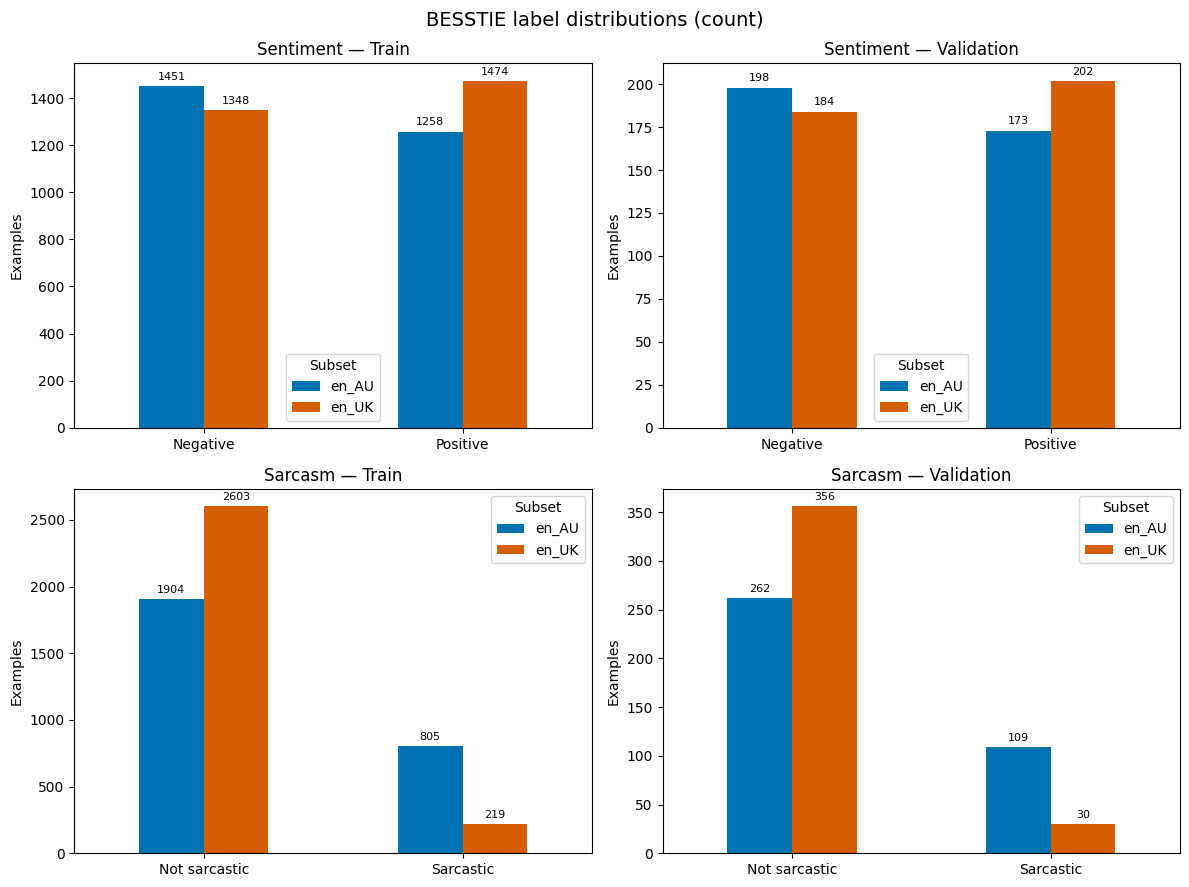

In [20]:
plot_label_distributions("count");

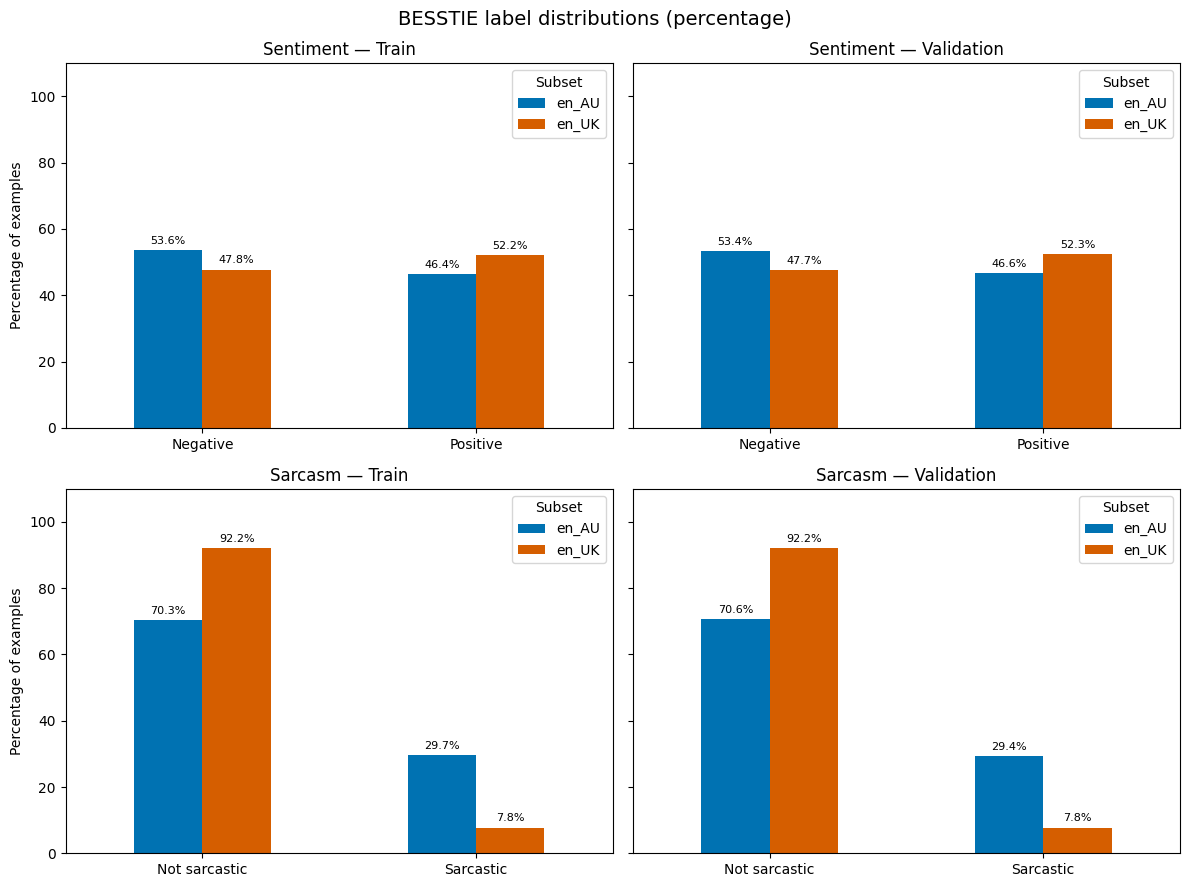

In [21]:
plot_label_distributions("percentage");

## Association between sarcasm and negative sentiment

Because both labels are binary, the **phi coefficient** (equivalent to Pearson correlation for two binary variables) measures association strength. Positive values mean sarcastic examples tend to be negative. We also compare negative-label rates, calculate an odds ratio, and use a chi-square test of independence.

As a rough guide for $|\phi|$: below 0.10 is negligible, 0.10–0.29 is small, 0.30–0.49 is moderate, and 0.50 or above is large. Statistical significance should be considered alongside effect size.

In [22]:
analysis_frame = pd.concat(
    [besstie[split].to_pandas().assign(split=split) for split in besstie],
    ignore_index=True,
)
analysis_frame["negative"] = 1 - analysis_frame["sentiment"]

assert analysis_frame[["sarcasm", "negative"]].isin([0, 1]).all().all()
analysis_frame[["subset", "split", "sentiment", "sarcasm", "negative"]].head()

,subset,split,sentiment,sarcasm,negative
0,en_AU,train,1,0,0
1,en_AU,train,1,0,0
2,en_AU,train,1,0,0
3,en_AU,train,1,0,0
4,en_AU,train,1,0,0


In [23]:
def binary_association(frame):
    """Summarise the association between sarcasm and negative sentiment."""
    table = pd.crosstab(frame["sarcasm"], frame["negative"]).reindex(
        index=[0, 1], columns=[0, 1], fill_value=0
    )
    phi = frame["sarcasm"].corr(frame["negative"])
    chi2, p_value, _, _ = chi2_contingency(table, correction=False)

    # Add 0.5 to every cell only when a zero would make the odds ratio undefined.
    odds_table = table.astype(float)
    if (odds_table == 0).any().any():
        odds_table += 0.5
    odds_ratio = (
        odds_table.loc[1, 1] * odds_table.loc[0, 0]
        / (odds_table.loc[1, 0] * odds_table.loc[0, 1])
    )

    negative_rate_sarcastic = frame.loc[frame["sarcasm"] == 1, "negative"].mean()
    negative_rate_not_sarcastic = frame.loc[frame["sarcasm"] == 0, "negative"].mean()
    return pd.Series({
        "n": len(frame),
        "n_sarcastic": frame["sarcasm"].sum(),
        "negative_rate_not_sarcastic": negative_rate_not_sarcastic,
        "negative_rate_sarcastic": negative_rate_sarcastic,
        "rate_difference": negative_rate_sarcastic - negative_rate_not_sarcastic,
        "phi": phi,
        "odds_ratio": odds_ratio,
        "chi2_p_value": p_value,
    })

In [24]:
association_rows = []
split_options = [*sorted(analysis_frame["split"].unique()), "all"]
subset_options = [*SUBSETS, "pooled"]

for split in split_options:
    split_frame = analysis_frame if split == "all" else analysis_frame.query("split == @split")
    for subset in subset_options:
        group = split_frame if subset == "pooled" else split_frame.query("subset == @subset")
        stats = binary_association(group).to_dict()
        association_rows.append({"split": split, "subset": subset, **stats})

association_results = pd.DataFrame(association_rows)
association_display = association_results.copy()
association_display[["n", "n_sarcastic"]] = association_display[["n", "n_sarcastic"]].astype(int)
for column in ["negative_rate_not_sarcastic", "negative_rate_sarcastic"]:
    association_display[column] = association_display[column].map(lambda value: f"{value:.1%}")
association_display["rate_difference"] = association_display["rate_difference"].map(lambda value: f"{value:+.1%}")
association_display["phi"] = association_display["phi"].map(lambda value: f"{value:+.3f}")
association_display["odds_ratio"] = association_display["odds_ratio"].map(lambda value: f"{value:.2f}")
association_display["chi2_p_value"] = association_display["chi2_p_value"].map(lambda value: f"{value:.3g}")
association_display

,split,subset,n,n_sarcastic,negative_rate_not_sarcastic,negative_rate_sarcastic,rate_difference,phi,odds_ratio,chi2_p_value
0,train,en_AU,2709,805,35.6%,96.1%,+60.6%,+0.555,45.25,1.24e-183
1,train,en_UK,2822,219,43.5%,98.6%,+55.1%,+0.295,93.56,1.77e-55
2,train,pooled,5531,1024,40.1%,96.7%,+56.5%,+0.439,43.43,4.41e-234
3,validation,en_AU,371,109,35.5%,96.3%,+60.8%,+0.555,47.70,1.03e-26
4,validation,en_UK,386,30,43.3%,100.0%,+56.7%,+0.304,79.95,2.29e-09
5,validation,pooled,757,139,40.0%,97.1%,+57.2%,+0.443,50.69,4.1e-34
6,all,en_AU,3080,914,35.5%,96.2%,+60.6%,+0.555,45.53,1.61e-208
7,all,en_UK,3208,249,43.5%,98.8%,+55.3%,+0.296,106.68,2.95e-63
8,all,pooled,6288,1163,40.1%,96.7%,+56.6%,+0.440,44.19,2.62e-266


### Check for source confounding

Google reviews and Reddit posts have different sentiment and sarcasm prevalences, so a pooled correlation may partly reflect source composition. The table below repeats the all-splits analysis within each source. Very small `n_sarcastic` values make an estimate unstable even when its point estimate is large.

In [25]:
source_rows = []
for source in sorted(analysis_frame["source"].unique()):
    source_frame = analysis_frame.query("source == @source")
    for subset in subset_options:
        group = source_frame if subset == "pooled" else source_frame.query("subset == @subset")
        stats = binary_association(group).to_dict()
        source_rows.append({"source": source, "subset": subset, **stats})

source_association_results = pd.DataFrame(source_rows)
source_association_display = source_association_results.copy()
source_association_display[["n", "n_sarcastic"]] = source_association_display[["n", "n_sarcastic"]].astype(int)
for column in ["negative_rate_not_sarcastic", "negative_rate_sarcastic"]:
    source_association_display[column] = source_association_display[column].map(lambda value: f"{value:.1%}")
source_association_display["rate_difference"] = source_association_display["rate_difference"].map(lambda value: f"{value:+.1%}")
source_association_display["phi"] = source_association_display["phi"].map(lambda value: f"{value:+.3f}")
source_association_display["odds_ratio"] = source_association_display["odds_ratio"].map(lambda value: f"{value:.2f}")
source_association_display["chi2_p_value"] = source_association_display["chi2_p_value"].map(lambda value: f"{value:.3g}")
source_association_display

,source,subset,n,n_sarcastic,negative_rate_not_sarcastic,negative_rate_sarcastic,rate_difference,phi,odds_ratio,chi2_p_value
0,google,en_AU,1076,73,21.7%,91.8%,+70.0%,+0.399,40.21,3.54e-39
1,google,en_UK,2065,1,25.1%,100.0%,+74.9%,+0.038,8.92,0.0847
2,google,pooled,3141,74,24.0%,91.9%,+67.9%,+0.236,35.83,7.39e-40
3,reddit,en_AU,2004,841,47.5%,96.6%,+49.1%,+0.520,30.99,1.12e-119
4,reddit,en_UK,1143,248,85.7%,98.8%,+13.1%,+0.169,13.63,1.02e-08
5,reddit,pooled,3147,1089,64.1%,97.1%,+33.0%,+0.365,18.51,5.14e-93


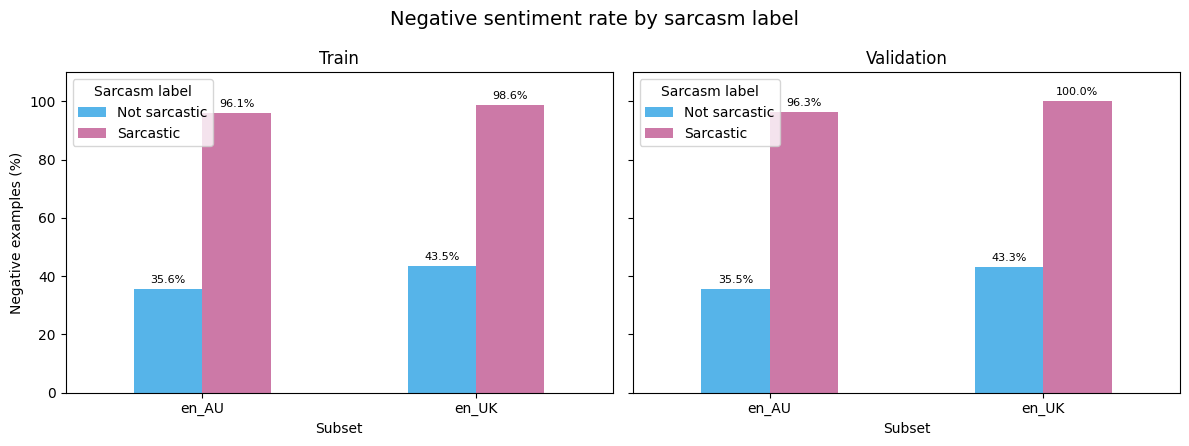

In [26]:
plot_frame = (
    analysis_frame.groupby(["split", "subset", "sarcasm"], observed=True)["negative"]
    .mean()
    .mul(100)
    .rename("negative_percentage")
    .reset_index()
)

splits = sorted(plot_frame["split"].unique())
fig, axes = plt.subplots(1, len(splits), figsize=(6 * len(splits), 4.5), sharey=True)
axes = np.atleast_1d(axes)
for ax, split in zip(axes, splits):
    pivot = (
        plot_frame.query("split == @split")
        .pivot(index="subset", columns="sarcasm", values="negative_percentage")
        .reindex(index=SUBSETS, columns=[0, 1])
        .rename(columns={0: "Not sarcastic", 1: "Sarcastic"})
    )
    pivot.plot(kind="bar", ax=ax, rot=0, color=["#56B4E9", "#CC79A7"])
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)
    ax.set_title(split.title())
    ax.set_xlabel("Subset")
    ax.set_ylabel("Negative examples (%)")
    ax.set_ylim(0, 110)
    ax.legend(title="Sarcasm label")

fig.suptitle("Negative sentiment rate by sarcasm label", fontsize=14)
fig.tight_layout()

### Data-driven conclusion

The following cell generates a concise interpretation from the pooled result and shows whether the same direction holds within each variety. Correlation describes association, not causation.

In [27]:
def effect_size_label(phi):
    magnitude = abs(phi)
    if magnitude < 0.10:
        return "negligible"
    if magnitude < 0.30:
        return "small"
    if magnitude < 0.50:
        return "moderate"
    return "large"

overall = association_results.query("split == 'all' and subset == 'pooled'").iloc[0]
direction = "more" if overall["rate_difference"] > 0 else "less"
significance = "statistically significant" if overall["chi2_p_value"] < 0.05 else "not statistically significant"

print(
    f"Across both subsets and splits, sarcastic examples are {direction} likely to be negative: "
    f"{overall['negative_rate_sarcastic']:.1%} versus "
    f"{overall['negative_rate_not_sarcastic']:.1%} for non-sarcastic examples."
)
print(
    f"The association is {effect_size_label(overall['phi'])} "
    f"(phi = {overall['phi']:+.3f}, odds ratio = {overall['odds_ratio']:.2f}) "
    f"and is {significance} (chi-square p = {overall['chi2_p_value']:.3g})."
)
print(
    "The source-stratified results should be used to judge robustness: a stratum with very few "
    "sarcastic examples cannot support a reliable standalone estimate."
)

by_subset = association_results.query("split == 'all' and subset != 'pooled'")[
    ["subset", "negative_rate_not_sarcastic", "negative_rate_sarcastic", "phi", "odds_ratio", "chi2_p_value"]
].copy()
for column in ["negative_rate_not_sarcastic", "negative_rate_sarcastic"]:
    by_subset[column] = by_subset[column].map(lambda value: f"{value:.1%}")
by_subset["phi"] = by_subset["phi"].map(lambda value: f"{value:+.3f}")
by_subset["odds_ratio"] = by_subset["odds_ratio"].map(lambda value: f"{value:.2f}")
by_subset["chi2_p_value"] = by_subset["chi2_p_value"].map(lambda value: f"{value:.3g}")
by_subset

Across both subsets and splits, sarcastic examples are more likely to be negative: 96.7% versus 40.1% for non-sarcastic examples.
The association is moderate (phi = +0.440, odds ratio = 44.19) and is statistically significant (chi-square p = 2.62e-266).
The source-stratified results should be used to judge robustness: a stratum with very few sarcastic examples cannot support a reliable standalone estimate.


,subset,negative_rate_not_sarcastic,negative_rate_sarcastic,phi,odds_ratio,chi2_p_value
6,en_AU,35.5%,96.2%,+0.555,45.53,1.61e-208
7,en_UK,43.5%,98.8%,+0.296,106.68,2.95e-63
